In [157]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error , r2_score
from math import sqrt
import pickle

In [158]:
dm = pd.read_csv("manufacturing.csv")

In [159]:
dm

,Temperature (°C),Pressure (kPa),Temperature x Pressure,Material Fusion Metric,Material Transformation Metric,Quality Rating
0,209.762701,8.050855,1688.769167,44522.217074,9.229576e+06,99.999971
1,243.037873,15.812068,3842.931469,63020.764997,1.435537e+07,99.985703
2,220.552675,7.843130,1729.823314,49125.950249,1.072839e+07,99.999758
3,208.976637,23.786089,4970.736918,57128.881547,9.125702e+06,99.999975
4,184.730960,15.797812,2918.345014,38068.201283,6.303792e+06,100.000000
...,...,...,...,...,...,...
3952,156.811578,21.794290,3417.596965,34941.963896,3.855501e+06,100.000000
3953,197.850406,8.291704,1640.516924,39714.857236,7.744742e+06,99.999997
3954,241.357144,16.391910,3956.304672,62657.690952,1.405957e+07,99.989318
3955,209.040239,23.809936,4977.234763,57195.985528,9.134036e+06,99.999975


In [160]:
dm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3957 entries, 0 to 3956
Data columns (total 6 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Temperature (°C)                3957 non-null   float64
 1   Pressure (kPa)                  3957 non-null   float64
 2   Temperature x Pressure          3957 non-null   float64
 3   Material Fusion Metric          3957 non-null   float64
 4   Material Transformation Metric  3957 non-null   float64
 5   Quality Rating                  3957 non-null   float64
dtypes: float64(6)
memory usage: 185.6 KB


In [161]:
dm.duplicated().sum()

np.int64(0)

In [162]:
dm.drop("Temperature x Pressure" , axis = 1 , inplace = True)

In [163]:
dm

,Temperature (°C),Pressure (kPa),Material Fusion Metric,Material Transformation Metric,Quality Rating
0,209.762701,8.050855,44522.217074,9.229576e+06,99.999971
1,243.037873,15.812068,63020.764997,1.435537e+07,99.985703
2,220.552675,7.843130,49125.950249,1.072839e+07,99.999758
3,208.976637,23.786089,57128.881547,9.125702e+06,99.999975
4,184.730960,15.797812,38068.201283,6.303792e+06,100.000000
...,...,...,...,...,...
3952,156.811578,21.794290,34941.963896,3.855501e+06,100.000000
3953,197.850406,8.291704,39714.857236,7.744742e+06,99.999997
3954,241.357144,16.391910,62657.690952,1.405957e+07,99.989318
3955,209.040239,23.809936,57195.985528,9.134036e+06,99.999975


In [164]:
dm = dm.rename(columns={
    'Temperature (°C)': 'temperature',
    'Pressure (kPa)': 'pressure',
    'Material Fusion Metric': 'mfm',
    'Material Transformation Metric': 'mtm',
    'Quality Rating': 'qr'
})

In [165]:
x = dm.drop("qr" , axis = 1)
y = dm.qr

In [166]:
X_train , X_test , y_train , y_test = train_test_split(x , y , test_size = 0.30 , random_state = 47)

In [167]:
model = LinearRegression()

In [168]:
model.fit(X_train , y_train)

LinearRegression()

In [169]:
y_pred_train = model.predict(X_train)

In [170]:
mean_squared_error(y_train , y_pred_train)

83.60401063465055

In [171]:
sqrt(mean_squared_error(y_train , y_pred_train))

9.143522878773288

In [172]:
r2_score(y_train , y_pred_train)

0.5123982753995893

In [173]:
y_pred_test = model.predict(X_test)

In [174]:
mean_squared_error(y_test , y_pred_test)

83.12674473553103

In [175]:
sqrt(mean_squared_error(y_test , y_pred_test))

9.117386946682204

In [176]:
r2_score(y_test , y_pred_test)

0.48824817297023115

In [254]:
poly = PolynomialFeatures(degree = 2)
X_train_poly2 = poly.fit_transform(X_train)
X_test_poly2  = poly.transform(X_test)


model_2 = LinearRegression()
model_2.fit(X_train_poly2 , y_train)

LinearRegression()

In [255]:
y_pred_poly2_train = model_2.predict(X_train_poly2)

In [256]:
mean_squared_error(y_pred_poly2_train , y_train)

31.982712126074837

In [257]:
sqrt(mean_squared_error(y_pred_poly2_train , y_train))

5.655325996445725

In [258]:
r2_score(y_pred_poly2_train , y_train)

0.7706953027200008

In [259]:
y_pred_poly2_test = model_2.predict(X_test_poly2)

In [260]:
mean_squared_error(y_pred_poly2_test , y_test)

31.12241302134851

In [261]:
sqrt(mean_squared_error(y_pred_poly2_test , y_test))

5.578746545716924

In [262]:
r2_score(y_pred_poly2_test , y_test)

0.7706444721296598

In [263]:
poly = PolynomialFeatures(degree = 4)
X_train_poly4 = poly.fit_transform(X_train)
X_test_poly4  = poly.transform(X_test)


model_3 = LinearRegression()
model_3.fit(X_train_poly4 , y_train)

LinearRegression()

In [264]:
y_pred_poly4_train = model_3.predict(X_train_poly4)

In [265]:
mean_squared_error(y_train , y_pred_poly4_train)

6.024529436708732

In [266]:
sqrt(mean_squared_error(y_pred_poly4_train , y_train))

2.454491686013365

In [267]:
r2_score(y_train , y_pred_poly4_train)

0.9648632772405824

In [268]:
y_pred_poly4_test = model_3.predict(X_test_poly4)

In [269]:
mean_squared_error(y_pred_poly4_test , y_test)

5.650860513724293

In [270]:
sqrt(mean_squared_error(y_pred_poly4_test , y_test))

2.3771538683316846

In [271]:
r2_score(y_pred_poly4_test , y_test)

0.9645502270791904

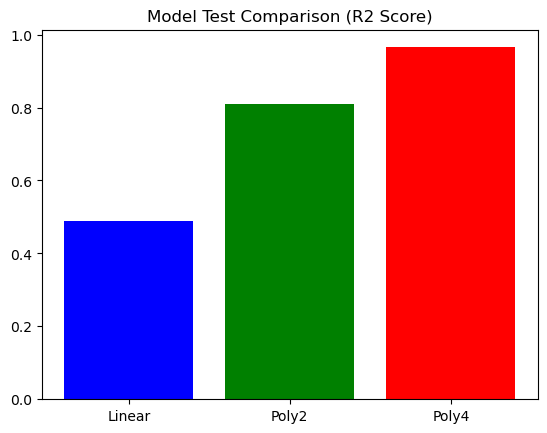

In [272]:
models = ['Linear', 'Poly2', 'Poly4']
scores = [
    r2_score(y_test, y_pred_test),
    r2_score(y_test, y_pred_poly2_test),
    r2_score(y_test, y_pred_poly4_test)
]

plt.bar(models, scores, color=['blue','green','red'])
plt.title("Model Test Comparison (R2 Score)")
plt.show()

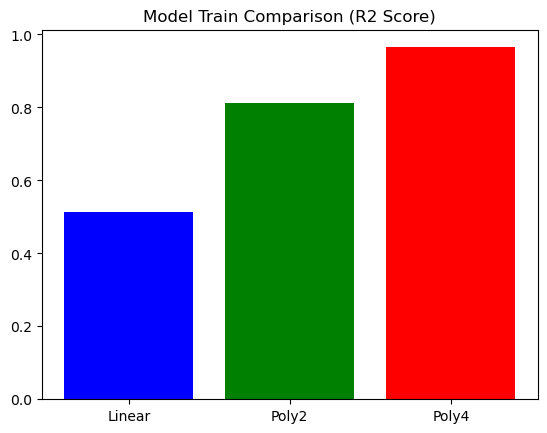

In [273]:
models = ['Linear', 'Poly2', 'Poly4']
scores = [
    r2_score(y_train, y_pred_train),
    r2_score(y_train, y_pred_poly2_train),
    r2_score(y_train, y_pred_poly4_train)
]

plt.bar(models, scores, color=['blue','green','red'])
plt.title("Model Train Comparison (R2 Score)")
plt.show()

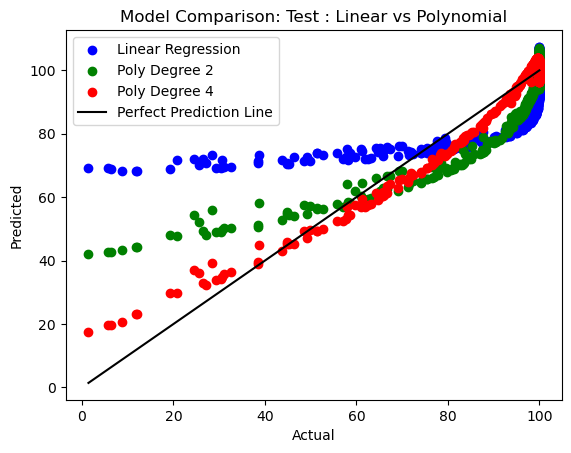

In [248]:
plt.scatter(y_test, y_pred_test, color='blue', label='Linear Regression')
plt.scatter(y_test, y_pred_poly2_test, color='green', label='Poly Degree 2')
plt.scatter(y_test, y_pred_poly4_test, color='red', label='Poly Degree 4')

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='black', label='Perfect Prediction Line')

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Model Comparison: Test : Linear vs Polynomial")
plt.legend()
plt.show()

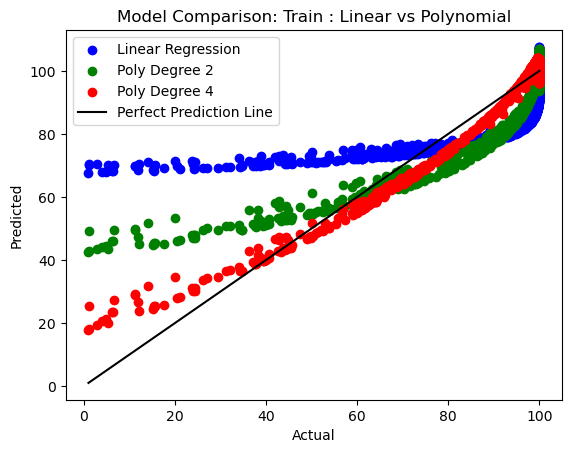

In [249]:
plt.scatter(y_train, y_pred_train, color='blue', label='Linear Regression')
plt.scatter(y_train, y_pred_poly2_train, color='green', label='Poly Degree 2')
plt.scatter(y_train, y_pred_poly4_train, color='red', label='Poly Degree 4')

plt.plot([y_train.min(), y_train.max()],
         [y_train.min(), y_train.max()],
         color='black', label='Perfect Prediction Line')

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Model Comparison: Train : Linear vs Polynomial")
plt.legend()
plt.show()

In [250]:
dm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3957 entries, 0 to 3956
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   temperature  3957 non-null   float64
 1   pressure     3957 non-null   float64
 2   mfm          3957 non-null   float64
 3   mtm          3957 non-null   float64
 4   qr           3957 non-null   float64
dtypes: float64(5)
memory usage: 154.7 KB


In [274]:
def Predict_Quality_Rating(temperature, pressure, mfm, mtm):

    input_data = [[temperature, pressure, mfm, mtm]]
    input_poly = poly.transform(input_data)
    rating = model_3.predict(input_poly)
    return rating

Temperature = float(input("Enter Temperature   :"))
Pressure    = float(input("Enter Pressure      :"))
MFM         = float(input("Enter MFM           :"))
MTM         = float(input("Enter MTM           :"))

result = Predict_Quality_Rating(Temperature , Pressure , MFM , MTM)
print(result)

Enter Temperature   : 12.4
Enter Pressure      : 13.4
Enter MFM           : 25.4
Enter MTM           : 26.4


[100.72029491]


C:\Users\Lenovo\anaconda2\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


In [275]:
with open('model_Predict_Quality_Rating.pkl' , 'wb') as f:
    pickle.dump(model_3 , f)